In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
df = pd.read_csv('../Data/Epileptic Seizure Recognition.csv')
df.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [4]:
df.shape

(11500, 180)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB


In [6]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,3.000000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,1.414275
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,1.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,2.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,4.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,5.000000


In [7]:
df['y'].value_counts()

y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

In [8]:
df = df.drop(['Unnamed'],axis=1)
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [9]:
X = df.drop(['y'],axis=1)
y = df['y']-1
X = StandardScaler().fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

In [11]:
X_train = torch.tensor(X_train, dtype = torch.float32).unsqueeze(1)
y_train = torch.tensor(y_train.values, dtype = torch.long)

In [12]:
X_test = torch.tensor(X_test, dtype = torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test.values, dtype = torch.long)

In [13]:
print(X_train.shape, X_train.dtype)
print(y_train.shape, y_train.dtype)
print(y_train.unique())

torch.Size([8625, 1, 178]) torch.float32
torch.Size([8625]) torch.int64
tensor([0, 1, 2, 3, 4])


In [14]:
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

batch_size = 128
train_l = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_l = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [15]:
n_classes = len(y_train.unique())
L = X_train.shape[2]

L

178

Text(0.5, 1.0, 'label 0')

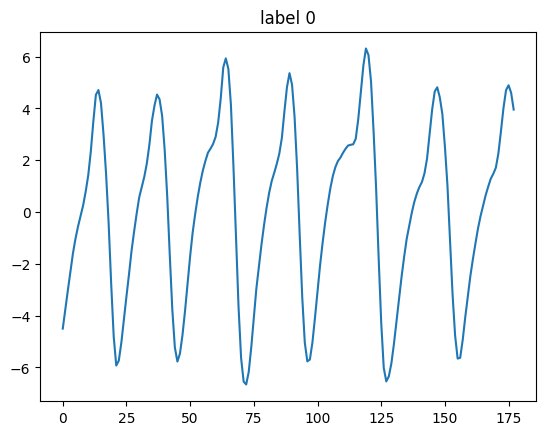

In [16]:
plt.plot(X_train[0].squeeze())
plt.title(f'label {y_train[0].item()}')

Text(0.5, 1.0, 'label 3')

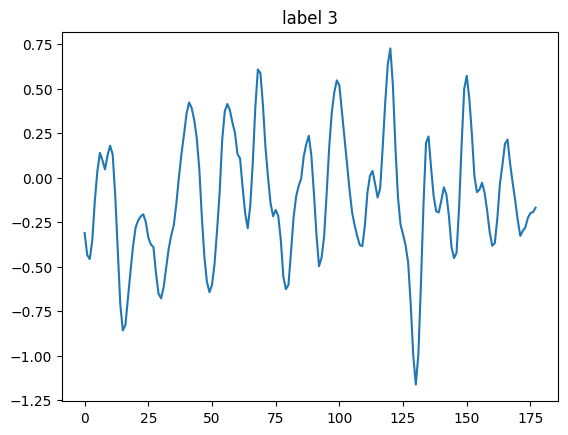

In [17]:
plt.plot(X_train[1].squeeze())
plt.title(f'label {y_train[1].item()}')

Text(0.5, 1.0, 'label 1')

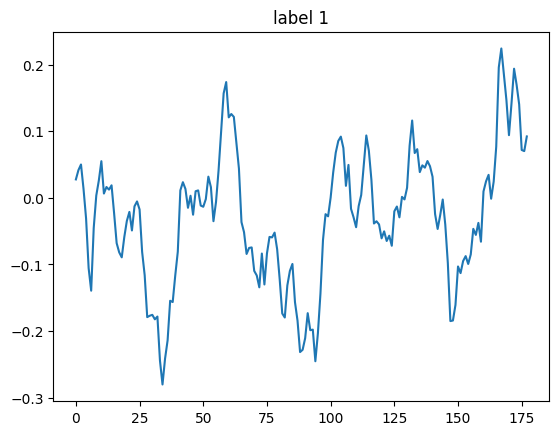

In [18]:
plt.plot(X_train[2].squeeze())
plt.title(f'label {y_train[2].item()}')

Text(0.5, 1.0, 'label 4')

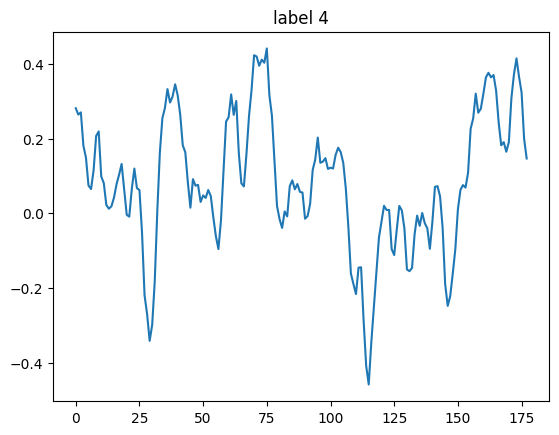

In [19]:
plt.plot(X_train[3].squeeze())
plt.title(f'label {y_train[3].item()}')

Helper function:

In [20]:
def cbr(in_ch, out_ch, k=3, stride=1):
    return nn.Sequential(
        nn.Conv1d(in_ch, out_ch, k, stride = stride, padding = (k-1)//2, bias = False),
        nn.BatchNorm1d(out_ch),
        nn.ReLU(inplace=True)
    )

In [21]:
def receptive_field(layers):
    rf, jump = 1, 1
    for k, s in layers:
        rf += (k - 1) * jump
        jump *= s
    return rf

layers, n = [], 0
while receptive_field(layers) < L:
    layers += [(3,1), (2,2)]
    n += 1
    print(n, receptive_field(layers), L // 2**n)

1 4 89
2 10 44
3 22 22
4 46 11
5 94 5
6 190 2


In [22]:
n_classes=5

In [23]:
def trace(model, L=187):
    hooks = []
    def hook(m, i, o):
        print(f'{m.__class__.__name__:<20} {tuple(o.shape)}')
    for m in model.modules():
        if not list(m.children()):
            hooks.append(m.register_forward_hook(hook))
    model(torch.randn(2, 1, L))
    for h in hooks:
        h.remove()

Dilated Resnet:

In [26]:
class DilResb(nn.Module):
    def __init__(self, ch, k=3, dilation=1):
        super().__init__()
        pad = dilation * (k-1)//2
        self.c1 = nn.Conv1d(ch, ch, k, padding=pad, dilation=dilation, bias=False)
        self.b1 = nn.BatchNorm1d(ch)
        self.c2 = nn.Conv1d(ch, ch, k, padding=pad, dilation=dilation, bias=False)
        self.b2 = nn.BatchNorm1d(ch)

    def forward(self, x):
        ip = x
        y = self.b1(self.c1(x))
        y = F.relu(y)
        y = self.b2(self.c2(y))
        return F.relu(y+ip)

In [28]:
class EEG_EpilepticSeizureRecognition_CNN1D(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.stem = cbr(1,64,k=7)
        self.d1 = DilResb(64, dilation=1)
        self.d2 = DilResb(64, dilation=2)
        self.d3 = DilResb(64, dilation=4)
        self.d4 = DilResb(64, dilation=8)
        self.d5 = DilResb(64, dilation=16)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.op = nn.Linear(64,n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.d1(x)
        x = self.d2(x)
        x = self.d3(x)
        x = self.d4(x)
        x = self.d5(x)
        x = self.gap(x).flatten(1)
        x = self.op(x)
        return x

model = EEG_EpilepticSeizureRecognition_CNN1D().to(device)
print(model)

EEG_EpilepticSeizureRecognition_CNN1D(
  (stem): Sequential(
    (0): Conv1d(1, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (d1): DilResb(
    (c1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (b1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (c2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (b2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (d2): DilResb(
    (c1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,), bias=False)
    (b1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (c2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,), bias=False)
    (b2): BatchNorm1d(64, ep

In [40]:
m = EEG_EpilepticSeizureRecognition_CNN1D(n_classes)
params = sum(p.numel() for p in m.parameters())
out = m(torch.randn(2, 1, 187)).shape
print(f'{EEG_EpilepticSeizureRecognition_CNN1D.__name__:20}     params:{params:>6}      out={tuple(out)}')

EEG_EpilepticSeizureRecognition_CNN1D     params:125061      out=(2, 5)


In [41]:
trace(EEG_EpilepticSeizureRecognition_CNN1D(n_classes))

Conv1d               (2, 64, 187)
BatchNorm1d          (2, 64, 187)
ReLU                 (2, 64, 187)
Conv1d               (2, 64, 187)
BatchNorm1d          (2, 64, 187)
Conv1d               (2, 64, 187)
BatchNorm1d          (2, 64, 187)
Conv1d               (2, 64, 187)
BatchNorm1d          (2, 64, 187)
Conv1d               (2, 64, 187)
BatchNorm1d          (2, 64, 187)
Conv1d               (2, 64, 187)
BatchNorm1d          (2, 64, 187)
Conv1d               (2, 64, 187)
BatchNorm1d          (2, 64, 187)
Conv1d               (2, 64, 187)
BatchNorm1d          (2, 64, 187)
Conv1d               (2, 64, 187)
BatchNorm1d          (2, 64, 187)
Conv1d               (2, 64, 187)
BatchNorm1d          (2, 64, 187)
Conv1d               (2, 64, 187)
BatchNorm1d          (2, 64, 187)
AdaptiveAvgPool1d    (2, 64, 1)
Linear               (2, 5)


In [45]:
def train_model(model, epochs=15, lr = 1e-3, criterion=None):
    torch.manual_seed(42)
    model = model.to(device)
    criterion = criterion or nn.CrossEntropyLoss()
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-2)
    tr_losses, te_losses = [],[]
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        tr_b_loss = []
        for X_b, y_b in train_l:
            X_b, y_b = X_b.to(device), y_b.to(device)
            pred = model(X_b)
            loss = criterion(pred, y_b)
            optim.zero_grad()
            loss.backward()
            optim.step()
            tr_b_loss.append(loss.item())
        tr_losses.append(np.mean(tr_b_loss))

        model.eval()
        te_b_loss=[]
        with torch.no_grad():
            for X_b, y_b in test_l:
                X_b, y_b = X_b.to(device), y_b.to(device)
                pred = model(X_b)
                loss = criterion(pred, y_b)
                te_b_loss.append(loss.item())
        te_losses.append(np.mean(te_b_loss))

        if(epoch+1)%2 == 0:
            print(f'Epoch: {epoch+1:2d}/{epochs}  |  Train Loss: {tr_losses[-1]:.6f}  |  Test Loss: {te_losses[-1]:.6f}')

    return model, tr_losses, te_losses, (time.time()-t0)/epochs



In [46]:
def evaluate(model, name = ''):
    model.eval()
    preds=[]
    with torch.no_grad():
        for X_b, _ in test_l:
            preds.append(model(X_b.to(device)).argmax(1).cpu())
    pred = torch.cat(preds)
    print(name)
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=3))
    return pred
    